# Customer Churn & Retention Analytics
## Notebook 4: Revenue at Risk & Retention Recommendations

### Final Business Impact Notebook

The purpose of this notebook is to convert customer churn analysis into
business-oriented decisions.

The analysis focuses on:

- RFM customer segmentation
- Customer value concentration
- Value associated with churned customers
- Value currently exposed to high-risk customers
- Churn reduction scenarios
- High-value customer churn
- Retention recommendations
- Executive-level business summary

### Important Data Limitation

The dataset does not contain actual sales revenue.

Therefore, **CashbackAmount is used as a customer monetary-value proxy**.

All monetary figures in this notebook represent estimated customer value
based on CashbackAmount and should not be presented as actual company revenue.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Import warnings to suppress unnecessary messages
import warnings
warnings.filterwarnings("ignore")

# Set pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Set professional visualization style
sns.set_theme(style="whitegrid", context="notebook")

# Define project color scheme
CHURN_COLOR = "#E74C3C"
RETAINED_COLOR = "#2ECC71"
NEUTRAL_COLOR = "#3498DB"

# Define project paths
CLEANED_FILE_PATH = "../data/cleaned/cleaned_ecommerce_churn.csv"
RISK_SEGMENT_FILE_PATH = "../data/cleaned/customer_risk_segments.csv"

MASTER_OUTPUT_PATH = "../data/cleaned/final_customer_churn_rfm.csv"
HIGH_RISK_OUTPUT_PATH = "../data/cleaned/high_risk_customers.csv"
METRICS_OUTPUT_PATH = "../data/cleaned/final_business_metrics.csv"

IMAGE_FOLDER = "../reports/images"

# Create required directories
import os
os.makedirs("../data/cleaned", exist_ok=True)
os.makedirs(IMAGE_FOLDER, exist_ok=True)

# Define RFM segment order
rfm_segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Lost Customers"
]

print("Customer Churn & Retention Analytics")
print("Notebook 4: Revenue at Risk & Retention Recommendations")
print("=" * 65)

Customer Churn & Retention Analytics
Notebook 4: Revenue at Risk & Retention Recommendations


## Load the Cleaned Dataset

The cleaned customer dataset from Notebook 1 is loaded first.

Notebook 3 created a separate customer-level risk file containing TenureCohort
and RiskLevel. We will load that file as well when it is available.

This keeps the cleaned master dataset separate from derived analytical segments.

In [2]:
# Load the cleaned master dataset
df = pd.read_csv(CLEANED_FILE_PATH)

# Display basic dataset information
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# Verify missing values
print(f"Missing Values: {df.isna().sum().sum():,}")

# Display churn summary
print("\nChurn Summary:")
display(
    df["Churn"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Retained", 1: "Churned"})
)

# Check whether Notebook 3 risk segmentation file exists
if os.path.exists(RISK_SEGMENT_FILE_PATH):
    risk_segments = pd.read_csv(RISK_SEGMENT_FILE_PATH)
    print("\nNotebook 3 risk-segment file found.")
    print(f"Risk Segment Rows: {len(risk_segments):,}")
else:
    risk_segments = None
    print("\nNotebook 3 risk-segment file not found.")
    print("Risk segments will be recreated in this notebook.")

Rows    : 5,630
Columns : 22
Missing Values: 0

Churn Summary:


Churn
Retained    4682
Churned      948
Name: count, dtype: int64


Notebook 3 risk-segment file found.
Risk Segment Rows: 5,630


### Prepare Risk-Level Information

Notebook 3 exported customer-level risk segments separately.

If that file exists, its RiskLevel and TenureCohort columns are merged into
the master dataset.

If it does not exist, the risk classification is recreated using the same
business rules used in Notebook 3.

This makes Notebook 4 robust and independently executable.

In [3]:
# Merge risk information from Notebook 3 when available
if risk_segments is not None:

    # Select only the derived columns required from Notebook 3
    risk_columns = [
        "CustomerID",
        "TenureCohort",
        "RiskLevel"
    ]

    available_risk_columns = [
        column for column in risk_columns
        if column in risk_segments.columns
    ]

    # Merge derived risk information using CustomerID
    df = df.merge(
        risk_segments[available_risk_columns],
        on="CustomerID",
        how="left",
        suffixes=("", "_NB3")
    )

    # Use Notebook 3 values where available
    if "TenureCohort_NB3" in df.columns:
        df["TenureCohort"] = df["TenureCohort"].fillna(
            df["TenureCohort_NB3"]
        )
        df.drop(columns=["TenureCohort_NB3"], inplace=True)

    if "RiskLevel_NB3" in df.columns:
        df["RiskLevel"] = df["RiskLevel"].fillna(
            df["RiskLevel_NB3"]
        )
        df.drop(columns=["RiskLevel_NB3"], inplace=True)

# Recreate missing lifecycle cohort if necessary
if "TenureCohort" not in df.columns:

    tenure_cohort_order = [
        "New (0-3m)",
        "Growing (4-6m)",
        "Established (7-12m)",
        "Mature (13-24m)",
        "Loyal (25m+)"
    ]

    df["TenureCohort"] = pd.cut(
        df["Tenure"],
        bins=[-np.inf, 3, 6, 12, 24, np.inf],
        labels=tenure_cohort_order,
        include_lowest=True
    )

# Recreate RiskLevel if necessary
if "RiskLevel" not in df.columns:

    critical_condition = (
        df["TenureCohort"].eq("New (0-3m)") &
        df["Complain"].eq(1) &
        df["SatisfactionScore"].le(2)
    )

    high_condition = (
        df["TenureCohort"].eq("New (0-3m)") &
        df["DaySinceLastOrder"].gt(30)
    )

    medium_condition = (
        df["TenureCohort"].eq("Growing (4-6m)") &
        df["SatisfactionScore"].le(2)
    )

    low_condition = (
        df["TenureCohort"].isin(
            ["Mature (13-24m)", "Loyal (25m+)"]
        ) &
        df["SatisfactionScore"].ge(4) &
        df["Complain"].eq(0)
    )

    df["RiskLevel"] = np.select(
        [
            critical_condition,
            high_condition,
            medium_condition,
            low_condition
        ],
        [
            "CRITICAL RISK",
            "HIGH RISK",
            "MEDIUM RISK",
            "LOW RISK"
        ],
        default="STANDARD RISK"
    )

# Display available derived fields
print("Derived analytical fields prepared successfully.")

display(
    df[
        [
            "CustomerID",
            "TenureCohort",
            "RiskLevel"
        ]
    ].head()
)

Derived analytical fields prepared successfully.


,CustomerID,TenureCohort,RiskLevel
0,50001,Growing (4-6m),MEDIUM RISK
1,50002,Established (7-12m),STANDARD RISK
2,50003,Established (7-12m),STANDARD RISK
3,50004,New (0-3m),STANDARD RISK
4,50005,New (0-3m),STANDARD RISK


## Section 2: RFM Customer Segmentation ⭐

RFM stands for:

- **Recency** → How recently the customer ordered
- **Frequency** → How frequently the customer orders
- **Monetary** → Customer monetary-value proxy

For this dataset:

- Recency = DaySinceLastOrder
- Frequency = OrderCount
- Monetary = CashbackAmount

Scoring:

- R_Score: 5 = most recent, 1 = least recent
- F_Score: 5 = most frequent, 1 = least frequent
- M_Score: 5 = highest value, 1 = lowest value

The combined RFM score ranges from 3 to 15.

In [4]:
# Create RFM dataframe
rfm_data = df[
    [
        "CustomerID",
        "Churn",
        "DaySinceLastOrder",
        "OrderCount",
        "CashbackAmount"
    ]
].copy()

# Rename columns to standard RFM terminology
rfm_data.rename(
    columns={
        "DaySinceLastOrder": "Recency",
        "OrderCount": "Frequency",
        "CashbackAmount": "Monetary"
    },
    inplace=True
)

# Create percentile-based scores using rank first to handle duplicate values
# Recency is reversed because lower recency is better
rfm_data["R_Score"] = pd.qcut(
    rfm_data["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency score: higher frequency receives higher score
rfm_data["F_Score"] = pd.qcut(
    rfm_data["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary score: higher monetary value receives higher score
rfm_data["M_Score"] = pd.qcut(
    rfm_data["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Calculate combined RFM score
rfm_data["RFM_Score"] = (
    rfm_data["R_Score"] +
    rfm_data["F_Score"] +
    rfm_data["M_Score"]
)

# Assign RFM segment based on total score
rfm_data["RFMSegment"] = pd.cut(
    rfm_data["RFM_Score"],
    bins=[2, 6, 9, 12, 15, 16],
    labels=[
        "Lost Customers",
        "At Risk",
        "Potential Loyalists",
        "Loyal Customers",
        "Champions"
    ],
    include_lowest=True
)

# Display RFM sample
display(rfm_data.head())

,CustomerID,Churn,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFMSegment
0,50001,1,5.00,1.00,159.93,2,1,3,6,Lost Customers
1,50002,1,0.00,1.00,120.90,5,1,1,7,At Risk
2,50003,1,3.00,1.00,120.28,4,1,1,6,Lost Customers
3,50004,1,3.00,1.00,134.07,4,1,1,6,Lost Customers
4,50005,1,3.00,1.00,129.60,4,1,1,6,Lost Customers


## Section 2: RFM Customer Segmentation ⭐

RFM stands for:

- **Recency** → How recently the customer ordered
- **Frequency** → How frequently the customer orders
- **Monetary** → Customer monetary-value proxy

For this dataset:

- Recency = DaySinceLastOrder
- Frequency = OrderCount
- Monetary = CashbackAmount

Scoring:

- R_Score: 5 = most recent, 1 = least recent
- F_Score: 5 = most frequent, 1 = least frequent
- M_Score: 5 = highest value, 1 = lowest value

The combined RFM score ranges from 3 to 15.

In [5]:
# Create RFM dataframe
rfm_data = df[
    [
        "CustomerID",
        "Churn",
        "DaySinceLastOrder",
        "OrderCount",
        "CashbackAmount"
    ]
].copy()

# Rename columns to standard RFM terminology
rfm_data.rename(
    columns={
        "DaySinceLastOrder": "Recency",
        "OrderCount": "Frequency",
        "CashbackAmount": "Monetary"
    },
    inplace=True
)

# Create percentile-based scores using rank first to handle duplicate values
# Recency is reversed because lower recency is better
rfm_data["R_Score"] = pd.qcut(
    rfm_data["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency score: higher frequency receives higher score
rfm_data["F_Score"] = pd.qcut(
    rfm_data["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary score: higher monetary value receives higher score
rfm_data["M_Score"] = pd.qcut(
    rfm_data["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Calculate combined RFM score
rfm_data["RFM_Score"] = (
    rfm_data["R_Score"] +
    rfm_data["F_Score"] +
    rfm_data["M_Score"]
)

# Assign RFM segment based on total score
rfm_data["RFMSegment"] = pd.cut(
    rfm_data["RFM_Score"],
    bins=[2, 6, 9, 12, 15, 16],
    labels=[
        "Lost Customers",
        "At Risk",
        "Potential Loyalists",
        "Loyal Customers",
        "Champions"
    ],
    include_lowest=True
)

# Display RFM sample
display(rfm_data.head())

,CustomerID,Churn,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFMSegment
0,50001,1,5.00,1.00,159.93,2,1,3,6,Lost Customers
1,50002,1,0.00,1.00,120.90,5,1,1,7,At Risk
2,50003,1,3.00,1.00,120.28,4,1,1,6,Lost Customers
3,50004,1,3.00,1.00,134.07,4,1,1,6,Lost Customers
4,50005,1,3.00,1.00,129.60,4,1,1,6,Lost Customers


### RFM Segment Performance

This table shows the size, churn rate, and average customer-value proxy
for each RFM segment.

The objective is to identify segments that are both:
- commercially valuable, and
- exposed to churn.

In [6]:
# Calculate RFM segment summary
rfm_summary = (
    rfm_data.groupby(
        "RFMSegment",
        observed=False
    )
    .agg(
        Customer_Count=("CustomerID", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean"),
        Avg_CashbackAmount=("Monetary", "mean")
    )
)

# Convert churn rate into percentage
rfm_summary["Churn_Rate"] = (
    rfm_summary["Churn_Rate"] * 100
)

# Reorder segments
rfm_summary = rfm_summary.reindex(rfm_segment_order)

# Display summary
display(rfm_summary.round(2))

,Customer_Count,Churned_Customers,Churn_Rate,Avg_CashbackAmount
RFMSegment,,,,
Champions,0,0,NaN,NaN
Loyal Customers,284,44,15.49,234.36
Potential Loyalists,2018,331,16.40,204.86
At Risk,2723,481,17.66,159.29
Lost Customers,605,92,15.21,138.94


## Section 3: RFM Segment Visualization

Three visualizations are used to understand the customer portfolio:

1. Treemap → customer population and churn intensity
2. Bar chart → churn rate by RFM segment
3. Scatter plot → Recency vs Monetary value

The purpose is to identify high-value customers who may require retention
attention.

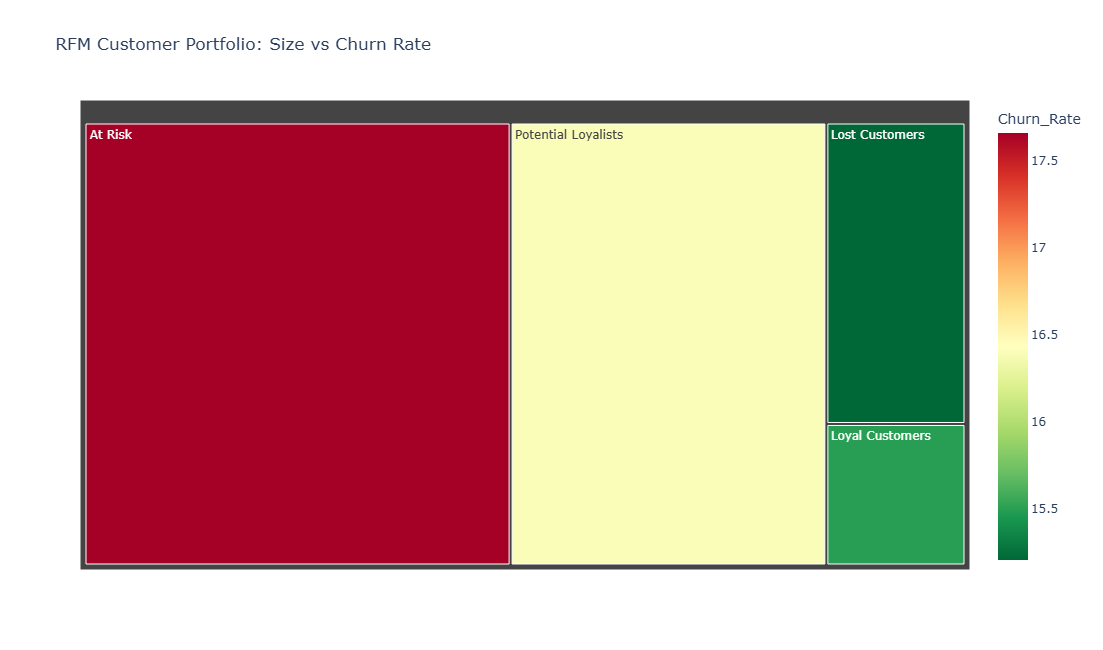

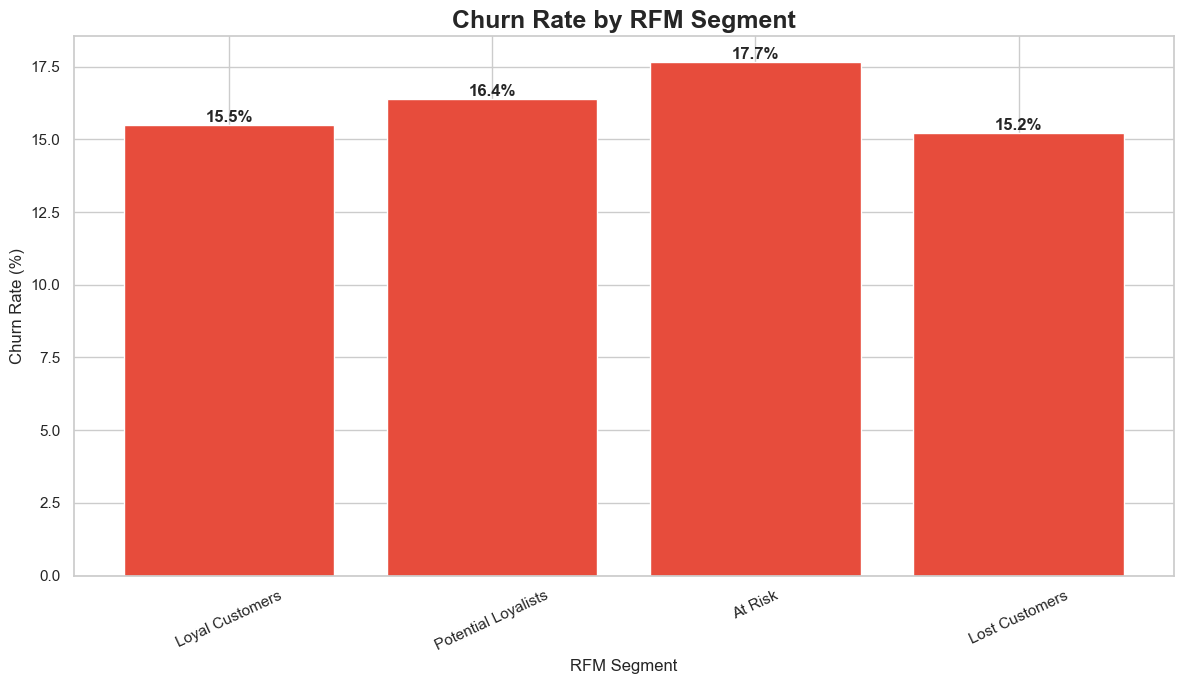

In [7]:
# Create RFM treemap
rfm_treemap = px.treemap(
    rfm_summary.reset_index(),
    path=["RFMSegment"],
    values="Customer_Count",
    color="Churn_Rate",
    color_continuous_scale="RdYlGn_r",
    title="RFM Customer Portfolio: Size vs Churn Rate",
    hover_data={
        "Customer_Count": True,
        "Churn_Rate": ":.2f",
        "Avg_CashbackAmount": ":.2f"
    }
)

# Configure treemap dimensions
rfm_treemap.update_layout(
    width=1100,
    height=650
)

# Display treemap
rfm_treemap.show()

# Save interactive treemap
rfm_treemap.write_html(
    f"{IMAGE_FOLDER}/rfm_customer_treemap.html"
)

# Create RFM churn-rate bar chart
plt.figure(figsize=(12, 7))

rfm_plot = rfm_summary.dropna(
    subset=["Churn_Rate"]
)

bars = plt.bar(
    rfm_plot.index.astype(str),
    rfm_plot["Churn_Rate"],
    color=CHURN_COLOR
)

# Add percentage labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Churn Rate by RFM Segment",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("RFM Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25)

plt.tight_layout()

# Save chart
plt.savefig(
    f"{IMAGE_FOLDER}/rfm_segment_churn_rate.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

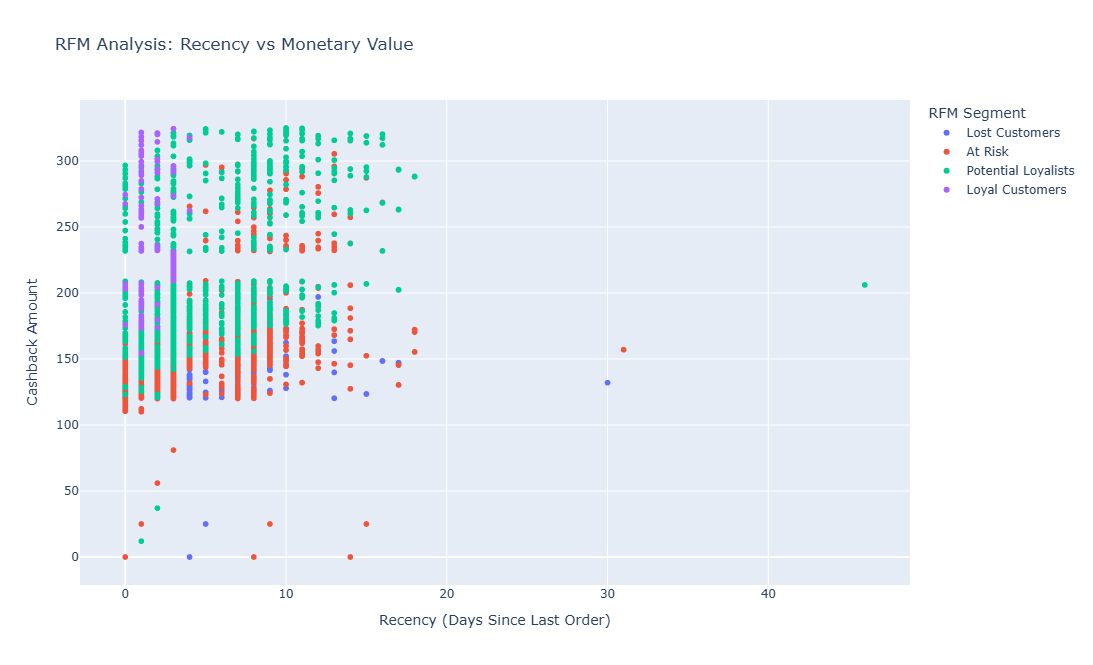

In [8]:
# Merge RFM information with the master customer dataset
df = df.merge(
    rfm_data[
        [
            "CustomerID",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Score",
            "RFMSegment"
        ]
    ],
    on="CustomerID",
    how="left"
)

# Create interactive Recency vs Monetary scatter plot
rfm_scatter = px.scatter(
    df,
    x="DaySinceLastOrder",
    y="CashbackAmount",
    color="RFMSegment",
    hover_data=[
        "CustomerID",
        "Churn",
        "OrderCount",
        "RFM_Score"
    ],
    title="RFM Analysis: Recency vs Monetary Value",
    labels={
        "DaySinceLastOrder": "Recency (Days Since Last Order)",
        "CashbackAmount": "Cashback Amount",
        "RFMSegment": "RFM Segment"
    }
)

# Configure chart size
rfm_scatter.update_layout(
    width=1100,
    height=650
)

# Display scatter plot
rfm_scatter.show()

# Save interactive scatter
rfm_scatter.write_html(
    f"{IMAGE_FOLDER}/rfm_recency_monetary_scatter.html"
)

## Section 4: Revenue / Customer-Value at Risk ⭐

Because actual sales revenue is not available, CashbackAmount is treated as
a **customer monetary-value proxy**.

We calculate:

1. Total customer-value proxy
2. Value associated with churned customers
3. Value-at-risk percentage
4. Value associated with CRITICAL and HIGH risk customers
5. Estimated value protected under 5% churn reduction
6. Estimated value protected under 10% churn reduction

The churn-reduction scenarios are scenario assumptions, not predictions.

In [9]:
# Calculate total customer-value proxy
total_customer_value = df["CashbackAmount"].sum()

# Calculate value associated with churned customers
value_lost_from_churn = df.loc[
    df["Churn"] == 1,
    "CashbackAmount"
].sum()

# Calculate value-at-risk percentage
value_at_risk_percentage = (
    value_lost_from_churn /
    total_customer_value *
    100
)

# Calculate value associated with currently high-risk customers
high_risk_condition = df["RiskLevel"].isin(
    ["CRITICAL RISK", "HIGH RISK"]
)

value_currently_at_risk = df.loc[
    high_risk_condition,
    "CashbackAmount"
].sum()

# Calculate 5% and 10% churn reduction scenarios
# These represent proportional reductions in currently churned customer value
value_saved_5_percent = (
    value_lost_from_churn * 0.05
)

value_saved_10_percent = (
    value_lost_from_churn * 0.10
)

# Create executive summary values
executive_metrics = {
    "Total Customer Base Value": total_customer_value,
    "Value Associated with Churned Customers": value_lost_from_churn,
    "Value Currently at Risk": value_currently_at_risk,
    "Value Protected at 5% Churn Reduction": value_saved_5_percent,
    "Value Protected at 10% Churn Reduction": value_saved_10_percent
}

# Print formatted executive summary
print("╔" + "═" * 49 + "╗")
print("║     REVENUE / CUSTOMER-VALUE IMPACT ANALYSIS   ║")
print("╠" + "═" * 49 + "╣")
print(
    f"║ Total Customer Base Value : ₹{total_customer_value:,.2f}"
)
print(
    f"║ Value Already Lost        : ₹{value_lost_from_churn:,.2f}"
)
print(
    f"║ Value Currently at Risk   : ₹{value_currently_at_risk:,.2f}"
)
print(
    f"║ 5% Churn Reduction Saves  : ₹{value_saved_5_percent:,.2f}"
)
print(
    f"║ 10% Churn Reduction Saves : ₹{value_saved_10_percent:,.2f}"
)
print("╚" + "═" * 49 + "╝")

print(
    f"\nValue associated with churned customers represents "
    f"{value_at_risk_percentage:.2f}% of total customer-value proxy."
)

╔═════════════════════════════════════════════════╗
║     REVENUE / CUSTOMER-VALUE IMPACT ANALYSIS   ║
╠═════════════════════════════════════════════════╣
║ Total Customer Base Value : ₹997,765.66
║ Value Already Lost        : ₹152,031.64
║ Value Currently at Risk   : ₹25,837.94
║ 5% Churn Reduction Saves  : ₹7,601.58
║ 10% Churn Reduction Saves : ₹15,203.16
╚═════════════════════════════════════════════════╝

Value associated with churned customers represents 15.24% of total customer-value proxy.


## Section 5: High-Value Customer Analysis — Pareto ⭐

The Pareto analysis investigates concentration of customer value.

We calculate:

- Top 20% customers by CashbackAmount
- Their share of total customer-value proxy
- Number of high-value customers who have churned
- Value associated with those churned high-value customers

This helps answer:

**"Are we losing a small number of disproportionately valuable customers?"**

HIGH-VALUE CUSTOMER / PARETO ANALYSIS
Top 20% customer count       : 1,126
Top 20% value contribution   : 29.35%
High-value customers churned : 100
Value associated with them   : ₹24,566.48


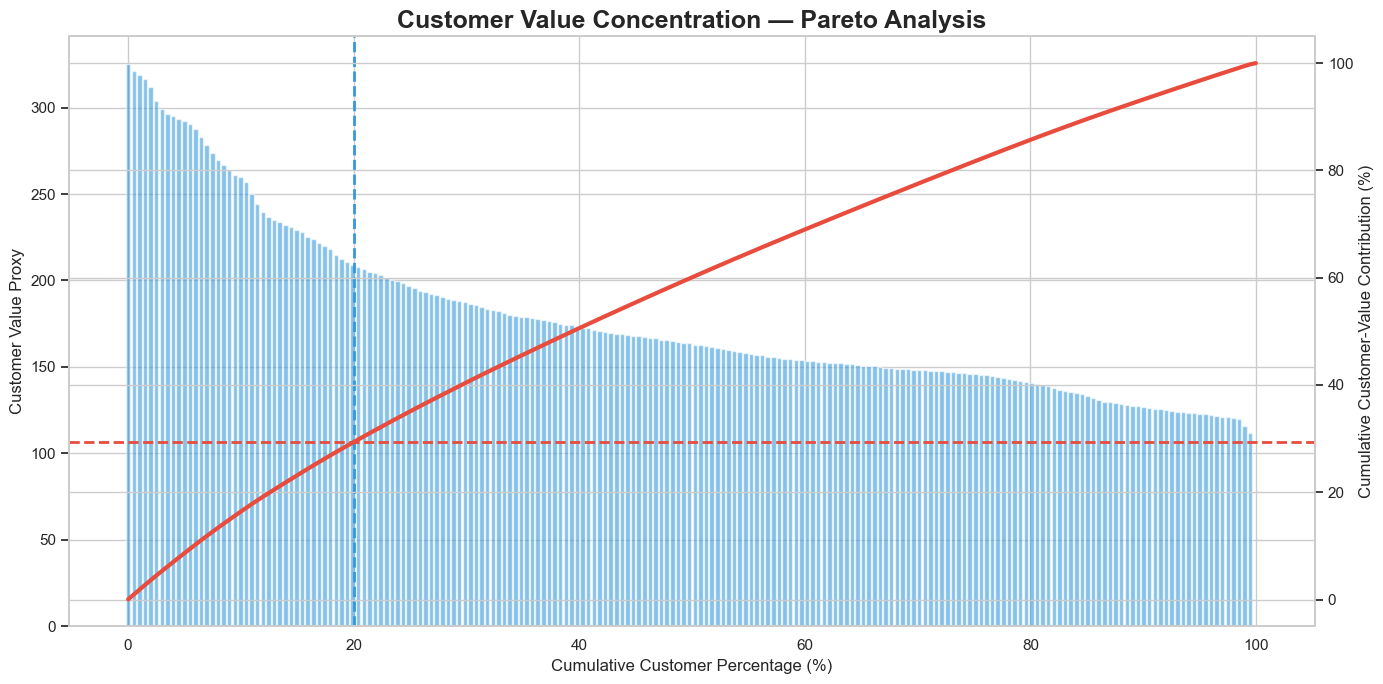

We lost 100 high-value customers associated with ₹24,566.48 of customer-value proxy.


In [10]:
# Sort customers by monetary value from highest to lowest
pareto_data = df[
    [
        "CustomerID",
        "CashbackAmount",
        "Churn",
        "RFMSegment"
    ]
].sort_values(
    "CashbackAmount",
    ascending=False
).reset_index(drop=True)

# Calculate cumulative customer percentage
pareto_data["Customer_Percentage"] = (
    (pareto_data.index + 1) /
    len(pareto_data) *
    100
)

# Calculate cumulative customer-value percentage
pareto_data["Cumulative_Value_Percentage"] = (
    pareto_data["CashbackAmount"].cumsum() /
    pareto_data["CashbackAmount"].sum() *
    100
)

# Identify top 20% customer count
top_20_percent_count = int(
    np.ceil(len(pareto_data) * 0.20)
)

# Extract top 20% customers
top_20_customers = pareto_data.head(
    top_20_percent_count
)

# Calculate top 20% value contribution
top_20_value_share = (
    top_20_customers["CashbackAmount"].sum() /
    total_customer_value *
    100
)

# Identify high-value churned customers
high_value_churned = top_20_customers[
    top_20_customers["Churn"] == 1
]

high_value_churned_count = len(
    high_value_churned
)

high_value_churned_value = (
    high_value_churned["CashbackAmount"].sum()
)

# Print Pareto findings
print("=" * 70)
print("HIGH-VALUE CUSTOMER / PARETO ANALYSIS")
print("=" * 70)

print(
    f"Top 20% customer count       : "
    f"{top_20_percent_count:,}"
)

print(
    f"Top 20% value contribution   : "
    f"{top_20_value_share:.2f}%"
)

print(
    f"High-value customers churned : "
    f"{high_value_churned_count:,}"
)

print(
    f"Value associated with them   : "
    f"₹{high_value_churned_value:,.2f}"
)

print("=" * 70)

# Create Pareto visualization
fig, axis_1 = plt.subplots(
    figsize=(14, 7)
)

# Plot customer value bars
# Use sampled customers when the dataset is large for readability
plot_step = max(1, len(pareto_data) // 200)

pareto_plot = pareto_data.iloc[::plot_step]

axis_1.bar(
    pareto_plot["Customer_Percentage"],
    pareto_plot["CashbackAmount"],
    width=0.4,
    alpha=0.6,
    color=NEUTRAL_COLOR
)

axis_1.set_xlabel(
    "Cumulative Customer Percentage (%)"
)
axis_1.set_ylabel(
    "Customer Value Proxy"
)

# Create secondary axis for cumulative value percentage
axis_2 = axis_1.twinx()

axis_2.plot(
    pareto_plot["Customer_Percentage"],
    pareto_plot["Cumulative_Value_Percentage"],
    color=CHURN_COLOR,
    linewidth=3
)

axis_2.set_ylabel(
    "Cumulative Customer-Value Contribution (%)"
)

# Add 20% reference line
axis_1.axvline(
    20,
    color=NEUTRAL_COLOR,
    linestyle="--",
    linewidth=2
)

axis_2.axhline(
    top_20_value_share,
    color=CHURN_COLOR,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Customer Value Concentration — Pareto Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save Pareto chart
plt.savefig(
    f"{IMAGE_FOLDER}/customer_value_pareto.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"We lost {high_value_churned_count:,} high-value customers "
    f"associated with ₹{high_value_churned_value:,.2f} "
    f"of customer-value proxy."
)

## Section 6: Customer Churn Intelligence Dashboard ⭐

This is the final executive visualization of the project.

The dashboard combines four perspectives:

1. Churn by lifecycle cohort
2. RFM portfolio distribution
3. Customer-value-at-risk breakdown
4. Top numerical churn associations

The purpose is not to show every analysis performed in previous notebooks,
but to provide a concise executive view.

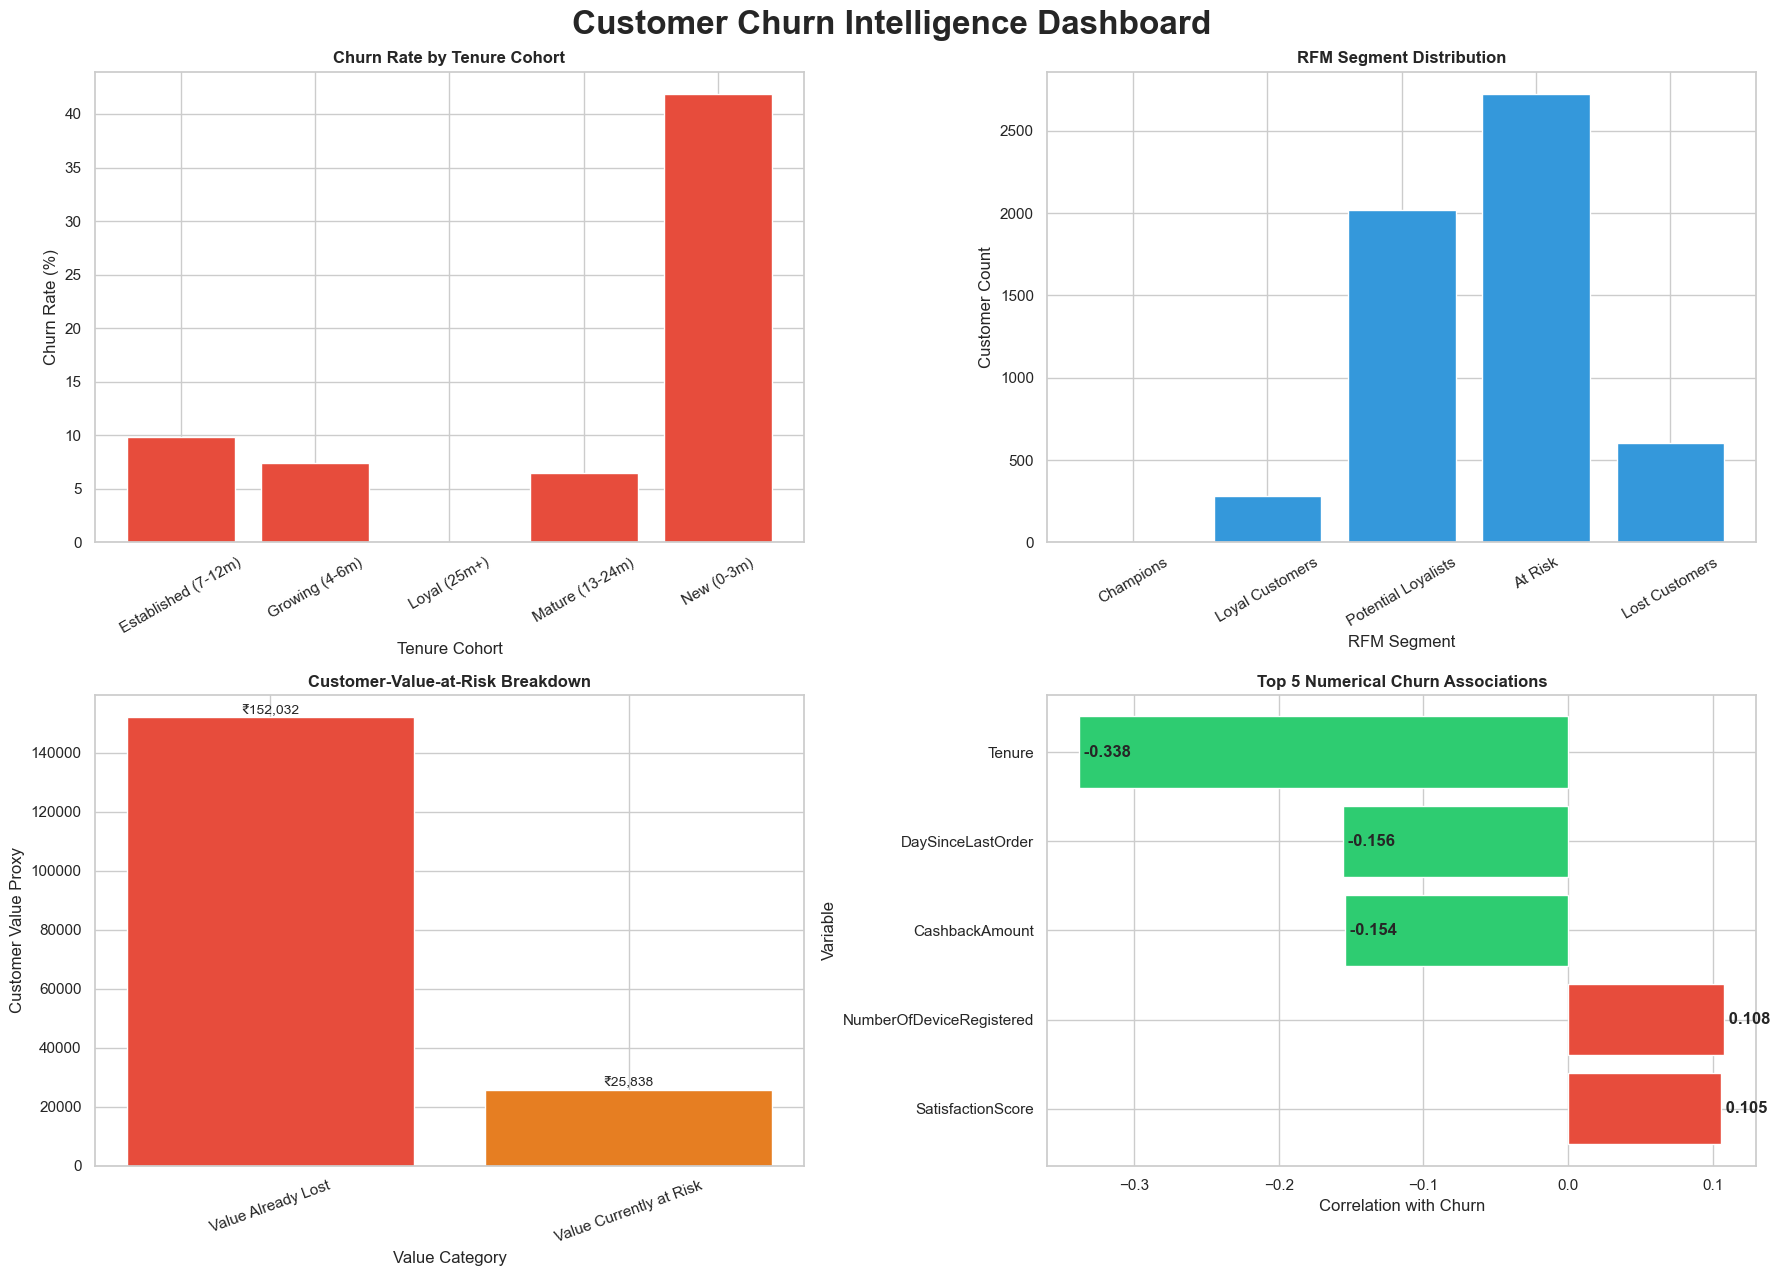

In [11]:
# Calculate churn rate by tenure cohort
cohort_dashboard = (
    df.groupby(
        "TenureCohort",
        observed=False
    )["Churn"]
    .mean()
    .mul(100)
)

# Calculate RFM segment distribution
rfm_distribution = (
    df["RFMSegment"]
    .value_counts()
    .reindex(rfm_segment_order)
    .fillna(0)
)

# Create value-at-risk breakdown
value_breakdown = pd.Series({
    "Value Already Lost": value_lost_from_churn,
    "Value Currently at Risk": value_currently_at_risk
})

# Calculate numerical correlations with churn
numeric_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

driver_correlations = (
    df[numeric_columns + ["Churn"]]
    .corr()["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

# Select top five absolute correlations
top_five_drivers = driver_correlations.head(5)

# Create four-panel dashboard
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 13)
)

# ---------------- Top Left ----------------
axes[0, 0].bar(
    cohort_dashboard.index.astype(str),
    cohort_dashboard.values,
    color=CHURN_COLOR
)

axes[0, 0].set_title(
    "Churn Rate by Tenure Cohort",
    fontweight="bold"
)
axes[0, 0].set_xlabel("Tenure Cohort")
axes[0, 0].set_ylabel("Churn Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=30)

# ---------------- Top Right ----------------
axes[0, 1].bar(
    rfm_distribution.index.astype(str),
    rfm_distribution.values,
    color=NEUTRAL_COLOR
)

axes[0, 1].set_title(
    "RFM Segment Distribution",
    fontweight="bold"
)
axes[0, 1].set_xlabel("RFM Segment")
axes[0, 1].set_ylabel("Customer Count")
axes[0, 1].tick_params(axis="x", rotation=30)

# ---------------- Bottom Left ----------------
axes[1, 0].bar(
    value_breakdown.index,
    value_breakdown.values,
    color=[CHURN_COLOR, "#E67E22"]
)

axes[1, 0].set_title(
    "Customer-Value-at-Risk Breakdown",
    fontweight="bold"
)
axes[1, 0].set_xlabel("Value Category")
axes[1, 0].set_ylabel("Customer Value Proxy")
axes[1, 0].tick_params(axis="x", rotation=20)

# Add value labels
for bar in axes[1, 0].patches:
    height = bar.get_height()

    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ---------------- Bottom Right ----------------
driver_colors = [
    CHURN_COLOR if value > 0 else RETAINED_COLOR
    for value in top_five_drivers.values
]

axes[1, 1].barh(
    top_five_drivers.index[::-1],
    top_five_drivers.values[::-1],
    color=driver_colors[::-1]
)

axes[1, 1].set_title(
    "Top 5 Numerical Churn Associations",
    fontweight="bold"
)
axes[1, 1].set_xlabel("Correlation with Churn")
axes[1, 1].set_ylabel("Variable")

# Add correlation labels
for position, value in enumerate(
    top_five_drivers.values[::-1]
):
    axes[1, 1].text(
        value,
        position,
        f" {value:.3f}",
        va="center",
        fontweight="bold"
    )

# Add dashboard title
fig.suptitle(
    "Customer Churn Intelligence Dashboard",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()

# Save high-resolution dashboard for PowerPoint
plt.savefig(
    f"{IMAGE_FOLDER}/customer_churn_intelligence_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Section 7: Retention Playbook ⭐

The recommendations below translate analytical findings into business actions.

Important:

The expected improvement percentages are **scenario assumptions**, not
predictions generated by the dataset.

Revenue/value saved is calculated from actual customer-value proxy associated
with the relevant churned population multiplied by the scenario impact.

This distinction is important for professional business analysis.

In [12]:
# ---------------- Recommendation 1 ----------------

# Identify churned customers in the New cohort
new_cohort_churned = df[
    (df["TenureCohort"] == "New (0-3m)") &
    (df["Churn"] == 1)
]

new_cohort_churn_rate = (
    df.loc[
        df["TenureCohort"] == "New (0-3m)",
        "Churn"
    ].mean() * 100
)

new_cohort_value_lost = (
    new_cohort_churned["CashbackAmount"].sum()
)

# Calculate scenario value saved at 10% and 15% improvement
new_program_value_saved_low = (
    new_cohort_value_lost * 0.10
)

new_program_value_saved_high = (
    new_cohort_value_lost * 0.15
)

# ---------------- Recommendation 2 ----------------

# Identify churned customers who complained
complainer_customers = df[
    df["Complain"] == 1
]

complainer_churned = df[
    (df["Complain"] == 1) &
    (df["Churn"] == 1)
]

complainer_churn_rate = (
    complainer_customers["Churn"].mean() * 100
)

non_complainer_churn_rate = (
    df.loc[
        df["Complain"] == 0,
        "Churn"
    ].mean() * 100
)

complainer_value_lost = (
    complainer_churned["CashbackAmount"].sum()
)

# Scenario assumes 20% reduction in complaint-associated churn
complaint_program_value_saved = (
    complainer_value_lost * 0.20
)

# ---------------- Recommendation 3 ----------------

# Define mid-tenure customers as 4-12 months
mid_tenure_condition = df["Tenure"].between(4, 12)

mid_tenure_churned = df[
    mid_tenure_condition &
    (df["Churn"] == 1)
]

mid_tenure_churn_rate = (
    df.loc[
        mid_tenure_condition,
        "Churn"
    ].mean() * 100
)

mid_tenure_value_lost = (
    mid_tenure_churned["CashbackAmount"].sum()
)

# Scenario value saved at 5% and 10% improvement
mid_tenure_value_saved_low = (
    mid_tenure_value_lost * 0.05
)

mid_tenure_value_saved_high = (
    mid_tenure_value_lost * 0.10
)

# Print formatted retention playbook
print("=" * 95)
print("                         RETENTION PLAYBOOK")
print("=" * 95)

print("\nRECOMMENDATION 1: EARLY ONBOARDING PROGRAM")
print("-" * 95)
print("Target      : New customers (0-3 months)")
print(
    f"Finding     : {new_cohort_churn_rate:.2f}% "
    f"churn rate in this cohort"
)
print(
    "Action      : 30-day onboarding journey + "
    "first-order cashback incentive"
)
print("Scenario    : 10-15% reduction in new-customer churn")
print(
    f"Value Saved : ₹{new_program_value_saved_low:,.2f} "
    f"to ₹{new_program_value_saved_high:,.2f}"
)

print("\nRECOMMENDATION 2: COMPLAINT RESOLUTION FAST-TRACK")
print("-" * 95)
print("Target      : Customers who have submitted complaints")
print(
    f"Finding     : {complainer_churn_rate:.2f}% churn among "
    f"complainers vs {non_complainer_churn_rate:.2f}% "
    f"among non-complainers"
)
print(
    "Action      : Priority resolution within 24 hours + "
    "post-resolution follow-up"
)
print("Scenario    : 20% reduction in complaint-associated churn")
print(
    f"Value Saved : ₹{complaint_program_value_saved:,.2f}"
)

print("\nRECOMMENDATION 3: LOYALTY REWARDS FOR MID-TENURE CUSTOMERS")
print("-" * 95)
print("Target      : Customers with 4-12 months tenure")
print(
    f"Finding     : {mid_tenure_churn_rate:.2f}% "
    f"observed churn rate in this population"
)
print(
    "Action      : Milestone rewards around 6-month and "
    "12-month relationship milestones"
)
print("Scenario    : 5-10% improvement in retention")
print(
    f"Value Saved : ₹{mid_tenure_value_saved_low:,.2f} "
    f"to ₹{mid_tenure_value_saved_high:,.2f}"
)

print("=" * 95)

                         RETENTION PLAYBOOK

RECOMMENDATION 1: EARLY ONBOARDING PROGRAM
-----------------------------------------------------------------------------------------------
Target      : New customers (0-3 months)
Finding     : 41.86% churn rate in this cohort
Action      : 30-day onboarding journey + first-order cashback incentive
Scenario    : 10-15% reduction in new-customer churn
Value Saved : ₹10,164.37 to ₹15,246.55

RECOMMENDATION 2: COMPLAINT RESOLUTION FAST-TRACK
-----------------------------------------------------------------------------------------------
Target      : Customers who have submitted complaints
Finding     : 31.67% churn among complainers vs 10.93% among non-complainers
Action      : Priority resolution within 24 hours + post-resolution follow-up
Scenario    : 20% reduction in complaint-associated churn
Value Saved : ₹16,194.93

RECOMMENDATION 3: LOYALTY REWARDS FOR MID-TENURE CUSTOMERS
----------------------------------------------------------------

### Recommendation Logic

The three recommendations address different stages of the customer lifecycle:

**Early stage → Prevent first-life churn**

**Complaint stage → Recover dissatisfied customers**

**Mid-tenure → Prevent customers from becoming inactive before they reach
long-term loyalty**

This creates a lifecycle-based retention strategy rather than a generic
"send more offers" recommendation.

In [13]:
# Create a structured recommendation dataframe
recommendation_summary = pd.DataFrame({
    "Recommendation": [
        "Early Onboarding Program",
        "Complaint Resolution Fast-Track",
        "Mid-Tenure Loyalty Rewards"
    ],
    "Target": [
        "New (0-3m)",
        "Customers with Complaints",
        "Tenure 4-12 Months"
    ],
    "Observed Churn Rate %": [
        new_cohort_churn_rate,
        complainer_churn_rate,
        mid_tenure_churn_rate
    ],
    "Expected Impact": [
        "10-15% churn reduction",
        "20% churn reduction",
        "5-10% retention improvement"
    ],
    "Estimated Value Saved Low": [
        new_program_value_saved_low,
        complaint_program_value_saved,
        mid_tenure_value_saved_low
    ],
    "Estimated Value Saved High": [
        new_program_value_saved_high,
        complaint_program_value_saved,
        mid_tenure_value_saved_high
    ]
})

# Display recommendation summary
display(
    recommendation_summary.round(2)
)

,Recommendation,Target,Observed Churn Rate %,Expected Impact,Estimated Value Saved Low,Estimated Value Saved High
0,Early Onboarding Program,New (0-3m),41.86,10-15% churn reduction,"10,164.37","15,246.55"
1,Complaint Resolution Fast-Track,Customers with Complaints,31.67,20% churn reduction,"16,194.93","16,194.93"
2,Mid-Tenure Loyalty Rewards,Tenure 4-12 Months,9.20,5-10% retention improvement,"1,589.80","3,179.60"


## Section 8: Export Final Datasets

Three outputs are created for downstream use:

1. **Final master dataset** with RFM scores and segments
2. **High-risk customer list** for targeted retention
3. **Business metrics summary** for the README, presentation, and dashboard

These outputs make the project reproducible and connect the Python analysis
to the final business presentation.

In [14]:
# Define master dataset columns
master_export_columns = [
    "CustomerID",
    "Churn",
    "Tenure",
    "TenureCohort",
    "RiskLevel",
    "DaySinceLastOrder",
    "OrderCount",
    "CashbackAmount",
    "SatisfactionScore",
    "Complain",
    "CityTier",
    "Gender",
    "R_Score",
    "F_Score",
    "M_Score",
    "RFM_Score",
    "RFMSegment"
]

# Keep only columns that actually exist
master_export_columns = [
    column
    for column in master_export_columns
    if column in df.columns
]

# Export master analytical dataset
df[master_export_columns].to_csv(
    MASTER_OUTPUT_PATH,
    index=False
)

# Define high-risk customer population
high_risk_customers = df[
    df["RiskLevel"].isin(
        [
            "CRITICAL RISK",
            "HIGH RISK"
        ]
    )
].copy()

# Select useful columns for retention targeting
high_risk_columns = [
    "CustomerID",
    "Churn",
    "Tenure",
    "TenureCohort",
    "RiskLevel",
    "DaySinceLastOrder",
    "OrderCount",
    "CashbackAmount",
    "SatisfactionScore",
    "Complain",
    "CityTier",
    "Gender",
    "RFM_Score",
    "RFMSegment"
]

high_risk_columns = [
    column
    for column in high_risk_columns
    if column in high_risk_customers.columns
]

# Export high-risk customer list
high_risk_customers[
    high_risk_columns
].to_csv(
    HIGH_RISK_OUTPUT_PATH,
    index=False
)

# Create key metrics summary
key_metrics = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate %",
        "Total Customer Value Proxy",
        "Value Associated with Churned Customers",
        "Value at Risk %",
        "Value Currently at Risk",
        "5% Churn Reduction Value",
        "10% Churn Reduction Value",
        "Top 20% Value Contribution %",
        "High-Value Churned Customers",
        "High-Value Churned Customer Value",
        "New Cohort Churn Rate %",
        "Complainer Churn Rate %",
        "Non-Complainer Churn Rate %",
        "Mid-Tenure Churn Rate %"
    ],
    "Value": [
        len(df),
        int(df["Churn"].sum()),
        int((df["Churn"] == 0).sum()),
        df["Churn"].mean() * 100,
        total_customer_value,
        value_lost_from_churn,
        value_at_risk_percentage,
        value_currently_at_risk,
        value_saved_5_percent,
        value_saved_10_percent,
        top_20_value_share,
        high_value_churned_count,
        high_value_churned_value,
        new_cohort_churn_rate,
        complainer_churn_rate,
        non_complainer_churn_rate,
        mid_tenure_churn_rate
    ]
})

# Export metrics
key_metrics.to_csv(
    METRICS_OUTPUT_PATH,
    index=False
)

# Print export confirmation
print("=" * 75)
print("FINAL DATA EXPORT COMPLETED")
print("=" * 75)

print(
    f"Master RFM Dataset : {MASTER_OUTPUT_PATH}"
)
print(
    f"High-Risk Customers: {HIGH_RISK_OUTPUT_PATH}"
)
print(
    f"Business Metrics   : {METRICS_OUTPUT_PATH}"
)

print("\nOutput Shapes:")
print(
    f"Master dataset     : "
    f"{df[master_export_columns].shape}"
)
print(
    f"High-risk dataset  : "
    f"{high_risk_customers.shape}"
)
print(
    f"Metrics summary    : "
    f"{key_metrics.shape}"
)

FINAL DATA EXPORT COMPLETED
Master RFM Dataset : ../data/cleaned/final_customer_churn_rfm.csv
High-Risk Customers: ../data/cleaned/high_risk_customers.csv
Business Metrics   : ../data/cleaned/final_business_metrics.csv

Output Shapes:
Master dataset     : (5630, 17)
High-risk dataset  : (167, 29)
Metrics summary    : (17, 2)


## Section 9: Final Project Summary

This final section produces the executive-level story of the entire
Customer Churn & Retention Analytics project.

The output can be used as the basis for:

- GitHub README
- PowerPoint presentation
- Tableau dashboard
- Interview project explanation

In [15]:
# Calculate final project statistics

total_customers = len(df)

churned_customers_count = int(
    df["Churn"].sum()
)

retained_customers_count = (
    total_customers -
    churned_customers_count
)

overall_churn_rate = (
    churned_customers_count /
    total_customers *
    100
)

# Identify highest and lowest RFM churn segments
highest_rfm_segment = (
    rfm_summary["Churn_Rate"]
    .idxmax()
)

highest_rfm_churn_rate = (
    rfm_summary["Churn_Rate"]
    .max()
)

lowest_rfm_segment = (
    rfm_summary["Churn_Rate"]
    .idxmin()
)

lowest_rfm_churn_rate = (
    rfm_summary["Churn_Rate"]
    .min()
)

# Print final executive summary
print("╔" + "═" * 78 + "╗")
print("║              CUSTOMER CHURN & RETENTION — FINAL SUMMARY              ║")
print("╠" + "═" * 78 + "╣")

print(
    f"║ Total Customers             : "
    f"{total_customers:,}"
)

print(
    f"║ Churned Customers           : "
    f"{churned_customers_count:,}"
)

print(
    f"║ Retained Customers          : "
    f"{retained_customers_count:,}"
)

print(
    f"║ Overall Churn Rate          : "
    f"{overall_churn_rate:.2f}%"
)

print(
    f"║ Total Customer Value Proxy  : "
    f"₹{total_customer_value:,.2f}"
)

print(
    f"║ Value Associated with Churn: "
    f"₹{value_lost_from_churn:,.2f}"
)

print(
    f"║ Value Currently at Risk     : "
    f"₹{value_currently_at_risk:,.2f}"
)

print(
    f"║ 5% Churn Reduction Scenario : "
    f"₹{value_saved_5_percent:,.2f}"
)

print(
    f"║ 10% Churn Reduction Scenario: "
    f"₹{value_saved_10_percent:,.2f}"
)

print(
    f"║ Top 20% Value Contribution  : "
    f"{top_20_value_share:.2f}%"
)

print(
    f"║ High-Value Customers Lost   : "
    f"{high_value_churned_count:,}"
)

print(
    f"║ High-Value Customer Value   : "
    f"₹{high_value_churned_value:,.2f}"
)

print("╚" + "═" * 78 + "╝")

print("\nKEY BUSINESS FINDINGS")
print("=" * 78)

print(
    f"\n1. The overall customer churn rate is "
    f"{overall_churn_rate:.2f}%."
)

print(
    f"\n2. {highest_rfm_segment} has the highest observed "
    f"RFM churn rate at {highest_rfm_churn_rate:.2f}%."
)

print(
    f"\n3. {lowest_rfm_segment} has the lowest observed "
    f"RFM churn rate at {lowest_rfm_churn_rate:.2f}%."
)

print(
    f"\n4. The top 20% of customers by CashbackAmount "
    f"represent {top_20_value_share:.2f}% of the "
    f"customer-value proxy."
)

print(
    f"\n5. {high_value_churned_count:,} high-value customers "
    f"have churned, associated with "
    f"₹{high_value_churned_value:,.2f} "
    f"of customer-value proxy."
)

print(
    f"\n6. Customers who complain churn at "
    f"{complainer_churn_rate:.2f}% compared with "
    f"{non_complainer_churn_rate:.2f}% among "
    f"non-complainers."
)

print(
    f"\n7. New customers have an observed churn rate of "
    f"{new_cohort_churn_rate:.2f}%."
)

print("\n" + "=" * 78)
print("FINAL BUSINESS MESSAGE")
print("=" * 78)

print(
    "\nThe analysis shows that customer retention should be managed as a "
    "lifecycle and value-prioritization problem."
)

print(
    "\nThe highest business opportunity is not simply reducing total churn. "
    "The company should prioritize customers based on lifecycle stage, "
    "customer value, engagement, satisfaction, and complaint status."
)

print(
    "\nThe recommended strategy is to protect new customers during onboarding, "
    "resolve complaints rapidly, and strengthen engagement during the "
    "mid-tenure lifecycle."
)

print(
    "\nAll monetary figures are customer-value estimates based on "
    "CashbackAmount and should not be interpreted as actual company revenue."
)

print(
    "\nNotebook 4 — Revenue at Risk & Retention Recommendations "
    "completed successfully."
)

╔══════════════════════════════════════════════════════════════════════════════╗
║              CUSTOMER CHURN & RETENTION — FINAL SUMMARY              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ Total Customers             : 5,630
║ Churned Customers           : 948
║ Retained Customers          : 4,682
║ Overall Churn Rate          : 16.84%
║ Total Customer Value Proxy  : ₹997,765.66
║ Value Associated with Churn: ₹152,031.64
║ Value Currently at Risk     : ₹25,837.94
║ 5% Churn Reduction Scenario : ₹7,601.58
║ 10% Churn Reduction Scenario: ₹15,203.16
║ Top 20% Value Contribution  : 29.35%
║ High-Value Customers Lost   : 100
║ High-Value Customer Value   : ₹24,566.48
╚══════════════════════════════════════════════════════════════════════════════╝

KEY BUSINESS FINDINGS

1. The overall customer churn rate is 16.84%.

2. At Risk has the highest observed RFM churn rate at 17.66%.

3. Lost Customers has the lowest observed RFM churn rate at 15.21%